# Cyclist DA Project
**By Chinedu Okafor**

**Last Modified:** 5/8/2026

---

## Business Task

The goal is to increase profitability by converting casual riders into annual members. To achieve this, we need to analyze how casual and member riders differ in their usage patterns in order to identify opportunities for targeted conversion strategies.

## Data Description

This analysis uses historical bike trip data from Q1 2021, including ride type (electric or classic bike), trip start and end times, start and end stations, geographic coordinates (latitude and longitude), and user type (casual or annual member).

**Note:** This analysis covers one quarter of data. Seasonal patterns — particularly summer leisure riding — are not captured and should be considered a limitation when interpreting findings.

## Metrics

The key metrics for this analysis include ride duration, time of day, day of the week, ride frequency, bike type preference, and user type distribution. These metrics are used to identify behavioral differences between casual riders and annual members, which inform targeted strategies for membership conversion.

## Hypothesis

The presence of morning and evening ride peaks suggests that annual members primarily use the service for commuting, while the more evenly distributed midday usage indicates that casual riders are more likely riding for leisure. Based on this pattern, the business can target casual riders during their peak midday usage periods with incentives such as limited-time membership trials or discounted subscriptions. Encouraging casual riders to adopt more consistent riding habits increases the likelihood of long-term membership conversion.

## Tools & Method
- **BigQuery (SQL)** — data cleaning, preparation, and initial aggregation analysis
- **Python (Google Colab)** — exploratory data analysis and statistical validation
- **Tableau** — final visualizations and interactive dashboard

Full SQL queries available in the project repository.

---
# Analysis

## Setup

Mount Google Drive and import the libraries required for data manipulation and visualization.

In [ ]:
# Mount Google Drive so the notebook can access files stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# pandas — for loading, manipulating, and aggregating the dataset
# matplotlib.pyplot — for creating charts and visualizations
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Define the path to the cleaned dataset stored in Google Drive
file_path = '/content/drive/MyDrive/MyDatasets/q1_2021_trips_clean_prepped.csv'

# Attempt to load the CSV file into a DataFrame
# Try/except handles the case where the file path is incorrect or the file is missing
try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully. Shape: {df.shape}")
    print(df.head(5))
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

/tmp/ipykernel_18291/4254922119.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully. Shape: (369271, 17)
            ride_id  rideable_type               started_at  \
0  C2A22C4428008FF2  electric_bike  2021-01-30 14:05:52 UTC   
1  5A5855645E03884E  electric_bike  2021-01-16 16:01:56 UTC   
2  9C7C0512C6FE69CD  electric_bike  2021-01-07 16:47:07 UTC   
3  1A54A32A66A4C41B  electric_bike  2021-01-14 18:35:00 UTC   
4  529541190411427A  electric_bike  2021-01-18 12:42:56 UTC   

                  ended_at       start_station_name start_station_id  \
0  2021-01-30 15:27:26 UTC                      NaN              NaN   
1  2021-01-16 16:14:30 UTC  Hegewisch Metra Station            20215   
2  2021-01-07 17:04:52 UTC                      NaN              NaN   
3  2021-01-14 19:03:09 UTC                      NaN              NaN   
4  2021-01-18 12:54:57 UTC                      NaN              NaN   

  end_station_name end_station_id  start_lat  start_lng  end_lat  end_lng  \
0              NaN            NaN  41.640000 -87.620000    41.

## Data Preparation

The dataset was pre-processed in BigQuery SQL, which calculated ride duration, extracted hour of day, and derived day of week. Here, datetime columns are converted to proper Python datetime objects to enable any additional time-based operations if needed.

In [ ]:
# Convert 'started_at' from a string to a datetime object
# This enables time-based operations such as extracting hour, day, or computing duration
df['started_at'] = pd.to_datetime(df['started_at'])

# Convert 'ended_at' from a string to a datetime object
# Required to calculate how long each ride lasted
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Confirm the new columns were created correctly by previewing the first 5 rows
df.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,month,ride_duration,hour,day_of_week
0,C2A22C4428008FF2,electric_bike,2021-01-30 14:05:52+00:00,2021-01-30 15:27:26+00:00,NaN,NaN,NaN,NaN,41.640000,-87.620000,41.66,-87.65,casual,Jan,81,14,Saturday
1,5A5855645E03884E,electric_bike,2021-01-16 16:01:56+00:00,2021-01-16 16:14:30+00:00,Hegewisch Metra Station,20215,NaN,NaN,41.648584,-87.546255,41.64,-87.51,casual,Jan,12,16,Saturday
2,9C7C0512C6FE69CD,electric_bike,2021-01-07 16:47:07+00:00,2021-01-07 17:04:52+00:00,NaN,NaN,NaN,NaN,41.650000,-87.540000,41.64,-87.51,casual,Jan,17,16,Thursday
3,1A54A32A66A4C41B,electric_bike,2021-01-14 18:35:00+00:00,2021-01-14 19:03:09+00:00,NaN,NaN,NaN,NaN,41.660000,-87.650000,41.68,-87.72,casual,Jan,28,18,Thursday
4,529541190411427A,electric_bike,2021-01-18 12:42:56+00:00,2021-01-18 12:54:57+00:00,NaN,NaN,NaN,NaN,41.660000,-87.650000,41.66,-87.65,casual,Jan,12,12,Monday


---
## Time of Day Analysis

Examining ride frequency by hour reveals whether members and casual riders use the service at different times of day — a key signal for distinguishing commute-driven from leisure-driven behavior.

In [ ]:
# Group rides by user type and hour of day, then count rides in each group
# This produces hourly ride totals separately for members and casual riders
# reset_index() flattens the result into a standard DataFrame with a named count column
time_analysis = df.groupby(['member_casual', 'hour']).size().reset_index(name='ride_count')

# Preview the first 5 rows to verify the grouping looks correct
time_analysis.head(5)

,member_casual,hour,ride_count
0,casual,0,1586
1,casual,1,1021
2,casual,2,427
3,casual,3,296
4,casual,4,336


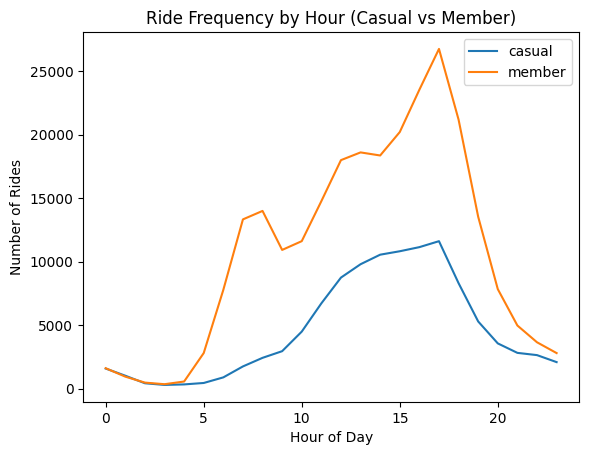

In [ ]:
# Plot hourly ride frequency as a line chart, with a separate line per user type
for user_type in df['member_casual'].unique():

    # Filter the aggregated data to only the current user type (member or casual)
    subset = time_analysis[time_analysis['member_casual'] == user_type]

    # Plot ride count across hours for this user type
    # The label argument feeds into the legend to distinguish the two lines
    plt.plot(subset['hour'], subset['ride_count'], label=user_type)

# Add legend, axis labels, and title for readability
plt.legend()
plt.title('Ride Frequency by Hour (Casual vs Member)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.show()

**Insight:** Annual members exhibit sharp increases in ride frequency during morning (7–9 AM) and evening (4–6 PM) hours, consistent with commuting behavior. In contrast, casual riders display a broader, more gradual increase throughout midday and afternoon hours, indicating more flexible, leisure-oriented usage rather than time-constrained travel.

Based on this pattern, the business can target casual riders during their peak midday usage with incentives such as limited-time membership trials or discounted subscriptions. Encouraging casual riders to shift toward more consistent, routine usage increases the likelihood of long-term membership conversion.

---
## Ride Duration Analysis

Comparing how long members and casual riders spend on each trip helps identify differences in intent. Shorter rides suggest purposeful, routine trips (commuting), while longer rides suggest leisure or exploration.

In [ ]:
# Calculate the average ride duration for each user type
# groupby separates the data into member and casual groups
# .mean() computes the average ride_duration within each group
# reset_index() returns a clean DataFrame instead of a grouped Series
duration_analysis = df.groupby('member_casual')['ride_duration'].mean().reset_index()

# Display the result to confirm average durations for each group
duration_analysis

,member_casual,ride_duration
0,casual,29.565685
1,member,13.521756


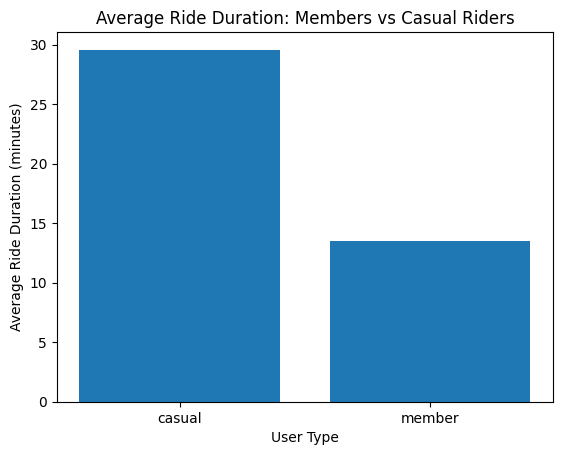

In [ ]:
# Create a bar chart comparing average ride duration between user types
plt.figure()

# x-axis: user type (member vs casual) | y-axis: average duration in minutes
plt.bar(duration_analysis['member_casual'], duration_analysis['ride_duration'])

plt.xlabel('User Type')
plt.ylabel('Average Ride Duration (minutes)')
plt.title('Average Ride Duration: Members vs Casual Riders')
plt.show()

### Ride Duration Distribution

Averages alone can be misleading — a small number of very long rides can inflate the mean. Examining the full distribution (median, spread, and outliers) gives a more accurate picture of typical ride behavior for each group.

#### Outlier Handling

Before plotting, we remove invalid records and cap extreme durations at the 95th percentile. Rides above this threshold likely represent bikes that were not properly returned or docked, rather than genuine trips.

In [ ]:
# Remove rides with zero or negative duration (data entry errors or system glitches)
# Also remove rides over 24 hours (1440 minutes) — almost certainly unreturned bikes
df_clean = df[(df['ride_duration'] > 0) & (df['ride_duration'] <= 1440)].copy()

# Separate the cleaned data into two groups for side-by-side comparison
member_durations = df_clean[df_clean['member_casual'] == 'member']['ride_duration']
casual_durations = df_clean[df_clean['member_casual'] == 'casual']['ride_duration']

# Print descriptive statistics for each group
# .describe() returns count, mean, std, min, quartiles, and max
# .round(2) keeps output readable
print("=== Member Ride Duration (minutes) ===")
print(member_durations.describe().round(2))
print()
print("=== Casual Ride Duration (minutes) ===")
print(casual_durations.describe().round(2))

=== Member Ride Duration (minutes) ===
count    258554.00
mean         13.52
std          26.12
min           1.00
25%           5.00
50%           9.00
75%          16.00
max        1418.00
Name: ride_duration, dtype: float64

=== Casual Ride Duration (minutes) ===
count    110717.00
mean         29.57
std          59.06
min           1.00
25%           9.00
50%          17.00
75%          32.00
max        1434.00
Name: ride_duration, dtype: float64


In [ ]:
# Examine the distribution of ride durations at key percentile cutoffs
# This informs where to set the cap for the boxplot — using data rather than an arbitrary number
print("Ride Duration Percentiles (minutes):")
print(df_clean['ride_duration'].quantile([0.90, 0.95, 0.99, 0.999]).round(2))

Ride Duration Percentiles (minutes):
0.900     35.00
0.950     51.00
0.990    115.00
0.999    591.19
Name: ride_duration, dtype: float64


95th percentile cap: 51.0 minutes
Rides retained: 351,225 of 369,271 (95.1%)


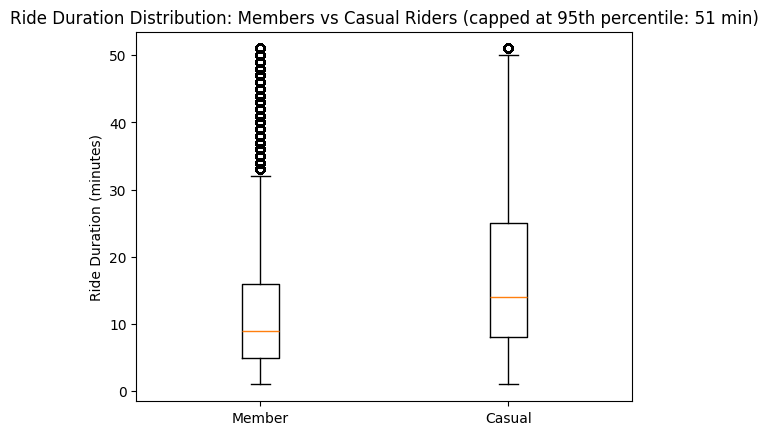

In [ ]:
# Set the cap at the 95th percentile — data-driven and more defensible than a fixed cutoff
# The top 5% of rides are excluded from the visualization only; they remain in the full dataset
cap = df_clean['ride_duration'].quantile(0.95)
df_capped = df_clean[df_clean['ride_duration'] <= cap]

# Print the cap value and how many rides were retained for transparency
print(f"95th percentile cap: {cap:.1f} minutes")
print(f"Rides retained: {len(df_capped):,} of {len(df_clean):,} ({len(df_capped)/len(df_clean)*100:.1f}%)")

# Build a boxplot comparing the distribution of ride durations for each user type
# The box shows the interquartile range (25th–75th percentile)
# The line inside the box is the median
# Whiskers extend to 1.5x the IQR; dots beyond are outliers within the capped range
plt.figure()
plt.boxplot(
    [df_capped[df_capped['member_casual'] == 'member']['ride_duration'],
     df_capped[df_capped['member_casual'] == 'casual']['ride_duration']],
    tick_labels=['Member', 'Casual']
)
plt.ylabel('Ride Duration (minutes)')
plt.title(f'Ride Duration Distribution: Members vs Casual Riders (capped at 95th percentile: {cap:.0f} min)')
plt.show()

**Insight:** Members ride with remarkable consistency — a median of ~9 minutes
and a tight IQR — reflecting habitual, purpose-driven trips. Casual riders show
a median of ~14 minutes with a much wider spread, confirming that their rides
vary significantly in length. The cluster of dots above Member's whisker are not
data errors; they represent members occasionally taking longer rides, which appear
extreme only because typical member rides are so short.

This pattern suggests that casual riders may not perceive strong value in a membership designed around frequent, short trips. To improve conversion, the business should position membership benefits in terms that resonate with occasional but longer-duration users — such as cost savings on extended rides or flexible plans that don't require daily commitment.

---
## Day of the Week Analysis

Analyzing ride patterns by day of the week reveals whether casual riders concentrate their usage on weekends (leisure) while members ride more consistently throughout the week (routine/commute).

In [ ]:
# Group rides by user type and day of the week, then count rides in each group
# This creates combinations such as 'member + Monday', 'casual + Saturday', etc.
# reset_index() converts the result into a clean DataFrame with a named count column
day_analysis = df.groupby(['member_casual', 'day_of_week']).size().reset_index(name='ride_count')

In [ ]:
# Define the correct calendar order for days of the week
# Without this, Pandas would sort days alphabetically (Friday, Monday, Saturday...)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert 'day_of_week' to an ordered categorical type using the defined day order
# This ensures any sorting or plotting follows the real-world day sequence
day_analysis['day_of_week'] = pd.Categorical(
    day_analysis['day_of_week'],
    categories=day_order,
    ordered=True
)

# Sort the DataFrame by day of week so rows run Monday through Sunday
day_analysis = day_analysis.sort_values('day_of_week')

# Preview the ordered result
day_analysis

,member_casual,day_of_week,ride_count
1,casual,Monday,14433
8,member,Monday,37372
5,casual,Tuesday,13178
12,member,Tuesday,39225
6,casual,Wednesday,11925
13,member,Wednesday,40020
4,casual,Thursday,8750
11,member,Thursday,33481
0,casual,Friday,11926
7,member,Friday,36545


In [ ]:
# Reshape from long format to wide format for grouped bar chart plotting
# index = day of week (rows), columns = user type, values = ride count
# This places member and casual counts side by side for each day
pivot_df = day_analysis.pivot(
    index='day_of_week',
    columns='member_casual',
    values='ride_count'
)

# Preview the reshaped data to confirm structure before plotting
pivot_df

member_casual,casual,member
day_of_week,,
Monday,14433,37372
Tuesday,13178,39225
Wednesday,11925,40020
Thursday,8750,33481
Friday,11926,36545
Saturday,29208,41251
Sunday,21297,30660


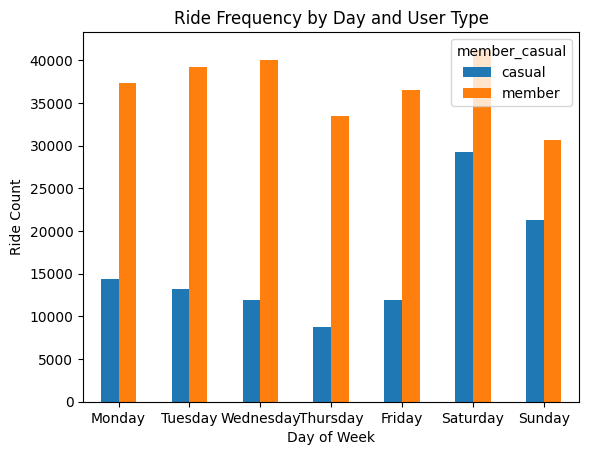

In [ ]:
# Plot a grouped bar chart — each day shows side-by-side bars for member vs casual riders
pivot_df.plot(kind='bar')

plt.xlabel('Day of Week')
plt.ylabel('Ride Count')
plt.title('Ride Frequency by Day and User Type')

# Rotate x-axis labels to horizontal for readability
plt.xticks(rotation=0)
plt.show()

**Insight:** Casual riders show a strong concentration of activity on weekends, with ride counts nearly doubling compared to weekdays — consistent with leisure-driven usage. Annual members maintain consistently high ride activity throughout the week with only a modest weekend increase, reflecting a routine commute-based pattern with some recreational use on weekends.

This weekday/weekend split is one of the clearest behavioral differences between the two groups. Membership marketing campaigns timed for Saturday and Sunday — when casual riders are already most engaged with the service — may yield the highest conversion rates.

---
## Bike Type Preference by User Type

The dataset distinguishes between electric and classic bikes. Analyzing whether members and casual riders show different preferences can reveal equipment allocation priorities and inform targeted promotions — for example, whether electric bike access could be used as a membership incentive.

In [ ]:
# Count rides grouped by user type and bike type
# This tells us how many rides each group took on each bike type
bike_analysis = df.groupby(['member_casual', 'rideable_type']).size().reset_index(name='ride_count')

# Calculate what share of each user type's total rides each bike type represents
# .transform('sum') computes the group total and broadcasts it back to each row
# This allows us to calculate a percentage within each user group
bike_analysis['total'] = bike_analysis.groupby('member_casual')['ride_count'].transform('sum')
bike_analysis['pct'] = (bike_analysis['ride_count'] / bike_analysis['total'] * 100).round(1)

# Display full breakdown including docked_bike for transparency
print("Full breakdown:")
print(bike_analysis[['member_casual', 'rideable_type', 'ride_count', 'pct']])

Full breakdown:
  member_casual  rideable_type  ride_count   pct
0        casual   classic_bike       58864  53.2
1        casual    docked_bike       18792  17.0
2        casual  electric_bike       33061  29.9
3        member   classic_bike      187183  72.4
4        member    docked_bike           1   0.0
5        member  electric_bike       71370  27.6


#### Data Cleaning Decision: Excluding Docked Bikes
Docked bike records were excluded from this analysis — members recorded only 1
docked ride across the entire quarter, making it a data artifact rather than a
meaningful category. Excluding it ensures percentages reflect the true
classic vs electric split and match the Tableau dashboard figures.

In [ ]:
# Remove docked_bike — data artifact, only 1 member ride recorded
# Excluding it makes percentages reflect the true classic vs electric split
bike_analysis_filtered = bike_analysis[
    bike_analysis['rideable_type'] != 'docked_bike'
].copy()

In [ ]:
# Recalculate percentages using filtered totals so they sum to 100%
bike_analysis_filtered['total'] = bike_analysis_filtered.groupby(
    'member_casual')['ride_count'].transform('sum')
bike_analysis_filtered['pct'] = (
    bike_analysis_filtered['ride_count'] /
    bike_analysis_filtered['total'] * 100
).round(1)

print("\nFiltered breakdown (docked_bike excluded):")
print(bike_analysis_filtered[['member_casual', 'rideable_type', 'ride_count', 'pct']])


Filtered breakdown (docked_bike excluded):
  member_casual  rideable_type  ride_count   pct
0        casual   classic_bike       58864  64.0
2        casual  electric_bike       33061  36.0
3        member   classic_bike      187183  72.4
5        member  electric_bike       71370  27.6


In [ ]:
# Reshape to wide format for grouped bar chart
# Percentage share used instead of raw counts for fair comparison between groups
# since members and casual riders have different total ride volumes
bike_pivot = bike_analysis_filtered.pivot(
    index='rideable_type',
    columns='member_casual',
    values='pct'
)

bike_pivot

member_casual,casual,member
rideable_type,,
classic_bike,64.0,72.4
electric_bike,36.0,27.6


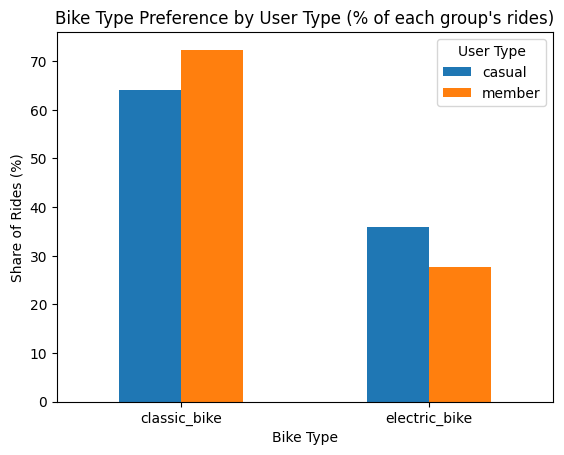

In [ ]:
# Plot grouped bar chart showing bike type preference as a % of each group's rides
bike_pivot.plot(kind='bar')
plt.xlabel('Bike Type')
plt.ylabel('Share of Rides (%)')
plt.title("Bike Type Preference by User Type (% of each group's rides)")
plt.xticks(rotation=0)
plt.legend(title='User Type')
plt.show()

**Insight:** Bike type preferences differ across user segments: members overwhelmingly favor classic bikes, while casual riders show relatively higher electric bike usage. Combined with longer ride durations and less pronounced commute peaks, this pattern suggests casual riders are more convenience-driven, whereas members prioritize efficiency and consistency. This difference highlights an opportunity to guide casual users toward more efficient ride options as part of the membership conversion process.

---
## Top Start Stations for Casual Riders

Identifying which stations casual riders use most frequently pinpoints the highest-opportunity locations for targeted outreach — both digital (location-triggered in-app promotions) and physical (on-site signage or staff). This output is also formatted for direct import into Tableau as a map data source.

**Data limitation:** A portion of rides are missing start station names, most commonly for electric bikes that do not require docking at a named station. These records are excluded from this analysis. The share of missing values is quantified below.

In [ ]:
# Quantify how many rides are missing start station data
# This documents the scope of the limitation before filtering it out
total = len(df)
missing_stations = df['start_station_name'].isna().sum()
pct_missing = (missing_stations / total * 100).round(1)

print(f"Total rides: {total:,}")
print(f"Missing start station name: {missing_stations:,} ({pct_missing}%)")
print(f"Rides with station data: {total - missing_stations:,} ({100 - pct_missing}%)")

# Check whether missing station names are concentrated in a specific bike type
# Electric bikes often don't require a named dock, which would explain the nulls
print("\nBike type breakdown for rides missing station name:")
print(df[df['start_station_name'].isna()]['rideable_type'].value_counts())

Total rides: 369,271
Missing start station name: 26,499 (7.2%)
Rides with station data: 342,772 (92.8%)

Bike type breakdown for rides missing station name:
rideable_type
electric_bike    26499
Name: count, dtype: int64


Approximately 7.2% of rides are missing start station names, primarily associated with electric bikes that do not require docking at fixed stations. These records were excluded from the station-level analysis, which may slightly underrepresent casual rider activity in non-docked scenarios.

In [ ]:
# Filter to casual riders with a valid start station name
# Rows with null station names are excluded — they cannot be mapped or counted by location
casual_stations = df[
    (df['member_casual'] == 'casual') &
    (df['start_station_name'].notna())
].copy()

# Count casual rides per station, keeping lat/lng for Tableau map export
# Grouping by coordinates alongside station name preserves location data in the output
# sort_values puts the highest-traffic stations at the top
station_counts = (
    casual_stations
    .groupby(['start_station_name', 'start_lat', 'start_lng'])
    .size()
    .reset_index(name='casual_ride_count')
    .sort_values('casual_ride_count', ascending=False)
)


# Displaying the top 10 stations as a quick preview
print("Top 10 Start Stations for Casual Riders:")
print(station_counts.head(10)[['start_station_name', 'casual_ride_count']])

Top 10 Start Stations for Casual Riders:
               start_station_name  casual_ride_count
12868   Lake Shore Dr & Monroe St               1943
22489     Streeter Dr & Grand Ave               1446
16506             Millennium Park                812
11272  Indiana Ave & Roosevelt Rd                762
22701         Theater on the Lake                755
15801      Michigan Ave & Lake St                653
13116  Lake Shore Dr & North Blvd                647
16507             Millennium Park                630
24050           Wells St & Elm St                608
15579       Michigan Ave & 8th St                601


Some stations appeared multiple times due to slight variations in recorded latitude and longitude values. To address this, station-level data was normalized by grouping entries by station name, consolidating duplicate records into a single representation. This ensured accurate identification of high-traffic locations without distortion from minor coordinate inconsistencies.

In [ ]:
casual_stations['start_lat'] = casual_stations['start_lat'].round(3)
casual_stations['start_lng'] = casual_stations['start_lng'].round(3)

station_counts = (
    casual_stations
    .groupby(['start_station_name', 'start_lat', 'start_lng'])
    .size()
    .reset_index(name='casual_ride_count')
    .sort_values('casual_ride_count', ascending=False)
)

# Displaying the top 10 stations as a quick preview
print("Top 10 Start Stations for Casual Riders:")
print(station_counts.head(10)[['start_station_name', 'casual_ride_count']])

Top 10 Start Stations for Casual Riders:
               start_station_name  casual_ride_count
589     Lake Shore Dr & Monroe St               2166
726               Millennium Park               1661
977       Streeter Dr & Grand Ave               1649
868                Shedd Aquarium               1193
514    Indiana Ave & Roosevelt Rd                975
703         Michigan Ave & Oak St                950
980           Theater on the Lake                895
713  Michigan Ave & Washington St                810
590    Lake Shore Dr & North Blvd                757
697        Michigan Ave & Lake St                734


                start_station_name  start_lat  start_lng  casual_ride_count
589      Lake Shore Dr & Monroe St     41.881    -87.617               2166
726                Millennium Park     41.881    -87.624               1661
977        Streeter Dr & Grand Ave     41.892    -87.612               1649
868                 Shedd Aquarium     41.867    -87.615               1193
514     Indiana Ave & Roosevelt Rd     41.868    -87.623                975
703          Michigan Ave & Oak St     41.901    -87.624                950
980            Theater on the Lake     41.926    -87.631                895
713   Michigan Ave & Washington St     41.884    -87.625                810
590     Lake Shore Dr & North Blvd     41.912    -87.627                757
697         Michigan Ave & Lake St     41.886    -87.624                734
1044         Wells St & Concord Ln     41.912    -87.635                702
1016        Wabash Ave & Grand Ave     41.891    -87.627                682
210         

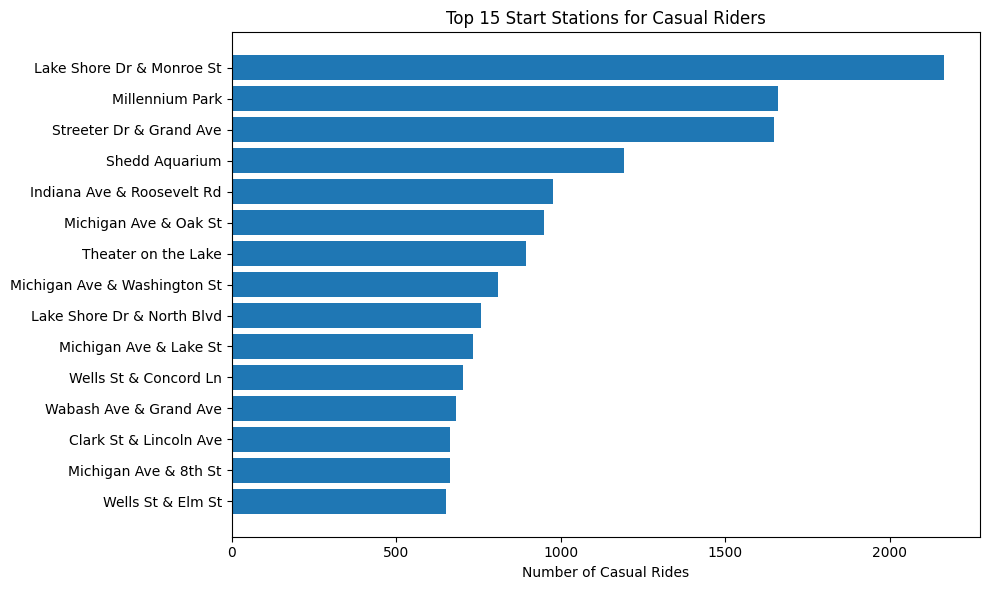

In [ ]:
# Select the top 15 stations for visualization
top_stations = station_counts.head(15)
print(top_stations)

# Horizontal bar chart makes long station names easier to read than a vertical chart
plt.figure(figsize=(10, 6))
plt.barh(top_stations['start_station_name'], top_stations['casual_ride_count'])
plt.xlabel('Number of Casual Rides')
plt.title('Top 15 Start Stations for Casual Riders')
plt.gca().invert_yaxis()  # Puts the highest-count station at the top of the chart
plt.tight_layout()         # Prevents station name labels from being cut off
plt.show()

In [ ]:
# Save directly to your Drive instead of the Colab temp environment
station_counts.head(50).to_csv('/content/drive/MyDrive/MyDatasets/top_casual_stations.csv', index=False)
print("Saved to Google Drive.")

Saved to Google Drive.


**Insight:** Casual rider activity clusters at a small number of high-traffic stations, many of which tend to be near parks, waterfronts, or tourist-adjacent areas — consistent with the leisure usage pattern identified in earlier analyses. These locations represent the highest-opportunity touchpoints for membership conversion efforts, both through in-app location-triggered promotions and physical on-site marketing.

Since casual riders are concentrated around high-traffic tourist and leisure locations, the business can implement location-based marketing strategies such as QR-code signage, limited-time membership trials, or app-based promotions triggered near these stations. This allows the company to reach users at the moment of engagement, increasing the likelihood of conversion.

The exported CSV (`top_casual_stations.csv`) includes station names, ride counts, and geographic coordinates, formatted for direct import into Tableau to build an interactive station-level map.

---
## Key Findings

Across all analyses, a consistent behavioral profile emerges for each user type:

**Annual Members**
- Peak ride activity during morning (7–9 AM) and evening (4–6 PM) hours — consistent with commuting
- Short, consistent ride durations with low variance, suggesting purposeful, routine trips
- Steady ride frequency across all weekdays, with a modest weekend increase

**Casual Riders**
- Gradual, midday-centered ride activity with no sharp commute peaks
- Significantly longer ride durations with a wider spread, indicating leisure-oriented usage
- Strong concentration of rides on weekends, with weekday usage roughly half that
- Activity clustered at a small number of high-traffic stations near parks and recreational areas

---
## Business Recommendations

**1. Time weekend promotions to capture peak casual engagement**
Casual rider activity peaks on Saturday and Sunday — the highest-leverage window for conversion campaigns. Limited-time trial memberships or weekend-only discounts offered in-app during these periods target riders at their most engaged.

**2. Reframe membership value for leisure users**
Casual riders take fewer but longer trips. Standard messaging around commute savings is unlikely to resonate. Instead, highlight cost savings on extended rides and position membership as a better deal for the type of riding casual users already do.

**3. Concentrate physical marketing at high-traffic casual stations**
The station analysis identifies a small number of locations that account for a disproportionate share of casual rides. On-site signage, QR codes, or promotional staff at these stations offers high reach with minimal distribution effort.

**4. Investigate electric bike access as a conversion lever**
If casual riders over-index on electric bikes relative to members, guaranteed electric bike access or a reduced electric ride rate could serve as a meaningful membership incentive for this group.

---
*Note: This analysis covers Q1 2021 only. Patterns may differ significantly in warmer months when leisure riding typically peaks. A full-year dataset is recommended before finalizing conversion strategy.*